# Datathon data understanding

In [1]:
from datathon_quality import *

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

files = sorted(DATA_DIR.glob("*.csv"))
file_inventory_df = build_file_inventory(files, TABLE_INFO)
file_inventory_df.sort_values(["layer", "table"])

,table,file,rows,columns,layer,grain,primary_key,business_use
10,sales,sales.csv,3833,3,Analytical,1 row per date,Date,Daily Revenue and COGS for training/analysis.
0,customers,customers.csv,121930,7,Master,1 row per customer,customer_id,"Customer profile, signup location, acquisition channel."
1,geography,geography.csv,39948,4,Master,1 row per zip code,zip,"City, region, district mapping."
6,products,products.csv,2412,8,Master,1 row per product,product_id,"Product attributes, retail price, product-level COGS."
7,promotions,promotions.csv,50,10,Master,1 row per promotion campaign,promo_id,"Discount type, timing, channel, stackability."
2,inventory,inventory.csv,60247,17,Operational,1 row per product per month snapshot,(composite/none),"Stockout, overstock, fill rate, sell-through."
12,web_traffic,web_traffic.csv,3652,7,Operational,1 row per date and traffic source,(composite/none),"Sessions, visitors, page views, bounce rate."
3,order_items,order_items.csv,714669,7,Transaction,1 row per product line inside an order,(composite/none),"Quantity, unit price, discount, product and promo usage."
4,orders,orders.csv,646945,8,Transaction,1 row per order,order_id,"Order date, status, customer, source, device, payment method."
5,payments,payments.csv,646945,4,Transaction,1 row per order payment,order_id,"Paid value, installments, payment method."


## 1. File inventory

## 1A. Clean visual overview

In [2]:
date_meta_df = build_date_meta(files)
table_overview = build_table_overview(file_inventory_df, date_meta_df)
overview_decision_matrix = build_decision_matrix(file_inventory_df)
plot_df = build_plot_df(file_inventory_df, date_meta_df)


In [3]:
display_table(
    table_overview,
    caption="table_overview - required output",
    formatters={"rows": "{:,}", "columns": "{:,}"},
)


,table_name,rows,columns,grain,primary_key,date_column,date_range,main_usage
0,customers,"121,930",7,1 row per customer,customer_id,signup_date,2012-01-17 to 2022-12-31,Master data for customer segmentation and acquisition analysis.
1,geography,"39,948",4,1 row per zip code,zip,,,Master data for region/district enrichment.
2,inventory,"60,247",17,1 row per product per month snapshot,,snapshot_date,2012-07-31 to 2022-12-31,Operational monthly stock snapshot; aggregate before sales joins.
3,order_items,"714,669",7,1 row per product line inside an order,,,,"Transaction line table for quantity, price, discount, revenue analysis."
4,orders,"646,945",8,1 row per order,order_id,order_date,2012-07-04 to 2022-12-31,"Transaction header for order date, customer, channel, status, device."
5,payments,"646,945",4,1 row per order payment,order_id,,,Transaction payment view for paid value and installment behavior.
6,products,"2,412",8,1 row per product,product_id,,,"Master data for product attributes, price, and COGS lookup."
7,promotions,50,10,1 row per promotion campaign,promo_id,"start_date, end_date",2013-01-31 to 2022-12-31,"Master data for campaign, discount, and promo eligibility context."
8,returns,"39,939",7,0 or many return rows per order/product,return_id,return_date,2012-07-11 to 2022-12-31,Transaction return/refund view; use to adjust net revenue and quality issues.
9,reviews,"113,551",7,0 or many review rows per order/product/customer,review_id,review_date,2012-07-10 to 2022-12-31,Transaction feedback view for ratings and post-purchase signals.


In [4]:
# display_table(
#     overview_decision_matrix,
#     caption="Decision matrix for usage and join preparation",
# )


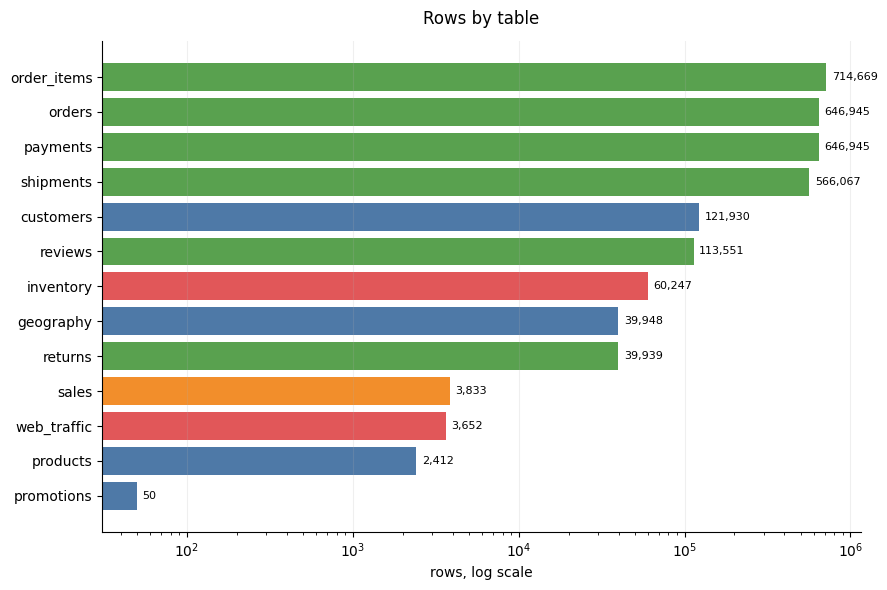

In [5]:
plot_rows_by_table(plot_df)


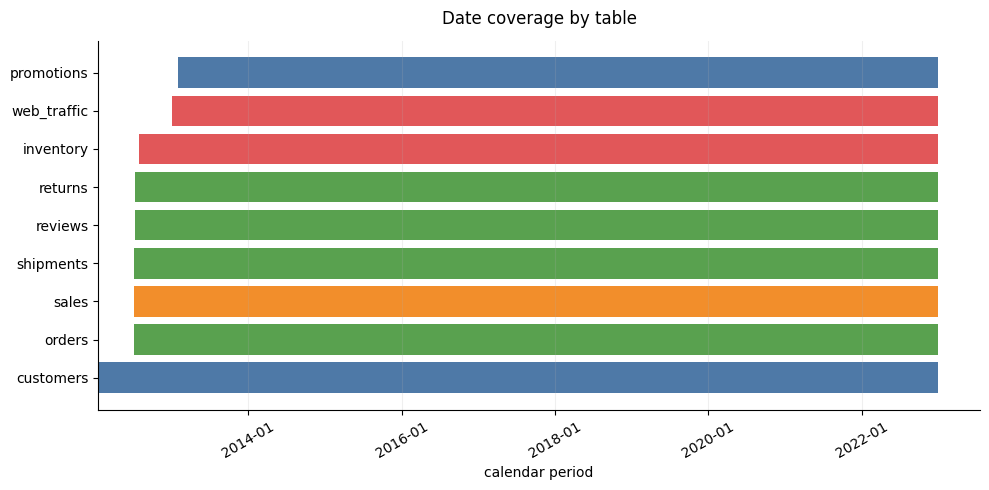

In [6]:
plot_date_coverage(plot_df)


In [7]:
# plot_join_preparation(overview_decision_matrix)

## 1B. Schema and column profiling

In [8]:
column_profile_summary = build_column_profile_summary(files)
table_type_summary = build_table_type_summary(column_profile_summary)
category_domain_summary = build_category_domain_summary(column_profile_summary, files)
numeric_profile_summary = build_numeric_profile_summary(column_profile_summary, files)
date_parse_summary = build_date_parse_summary(column_profile_summary, files)
dtype_issues = build_dtype_issues(column_profile_summary, files)


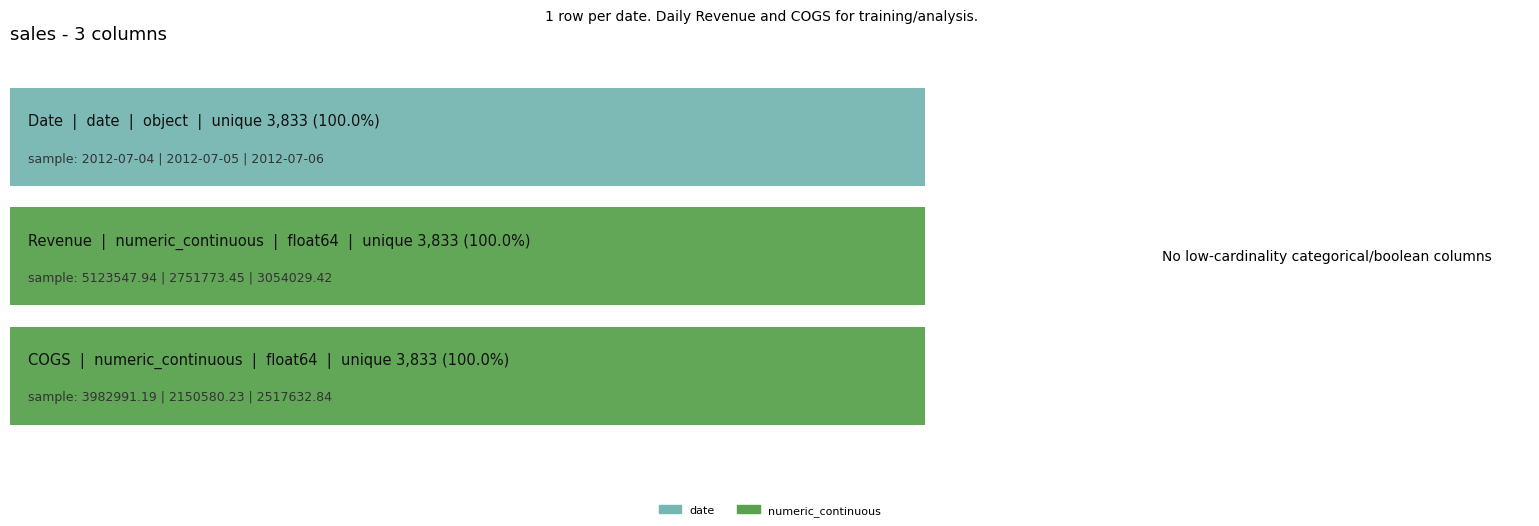

In [9]:
plot_core_table_profile("sales", column_profile_summary)


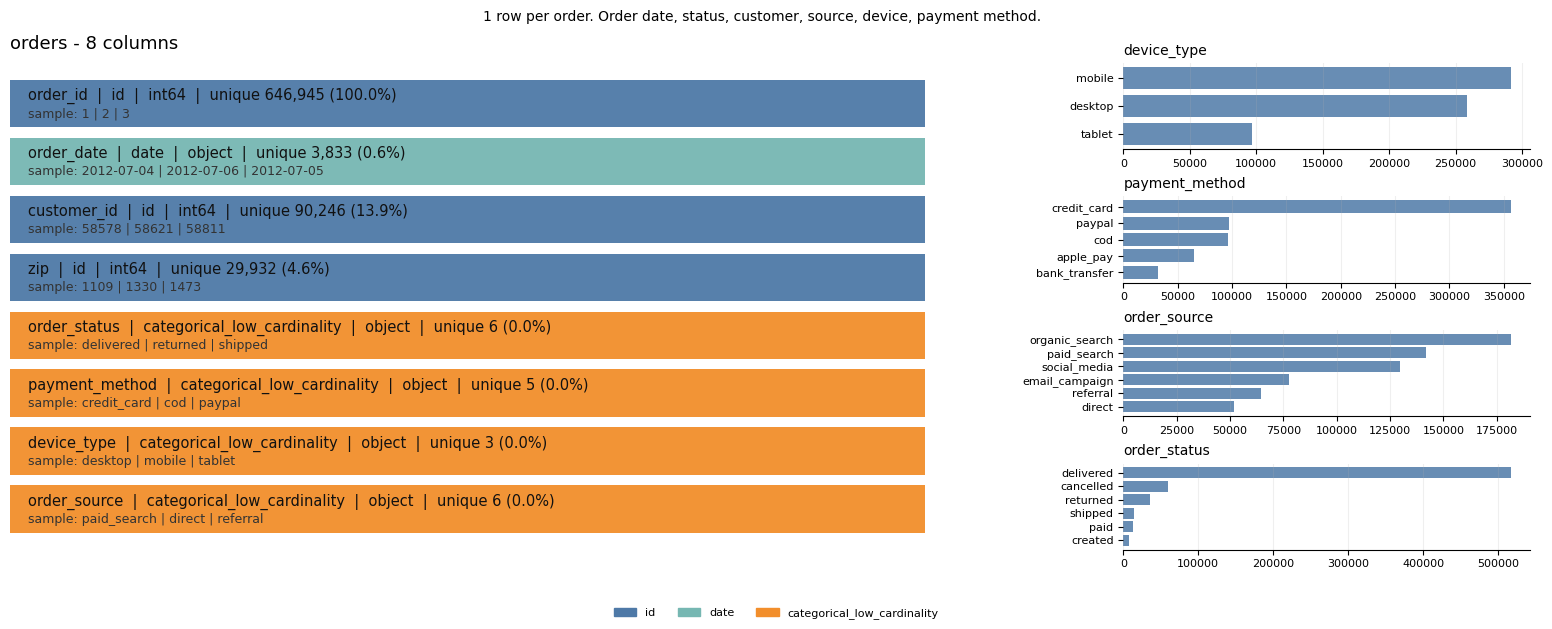

In [10]:
plot_core_table_profile("orders", column_profile_summary)


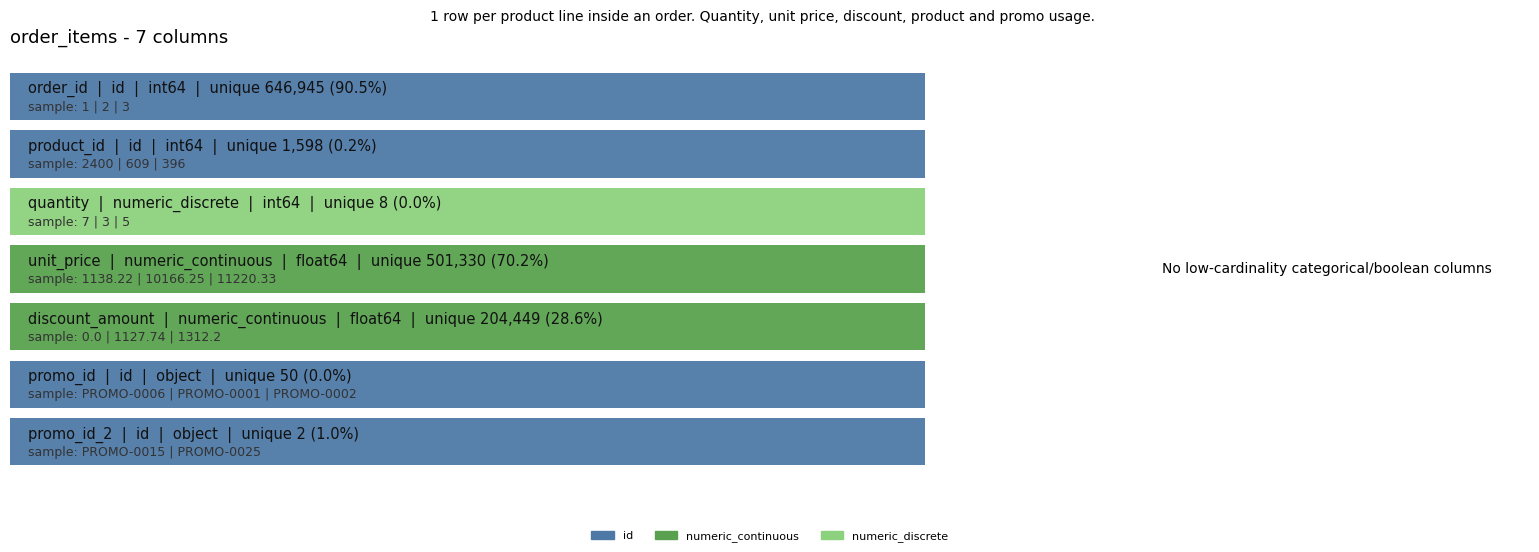

In [11]:
plot_core_table_profile("order_items", column_profile_summary)


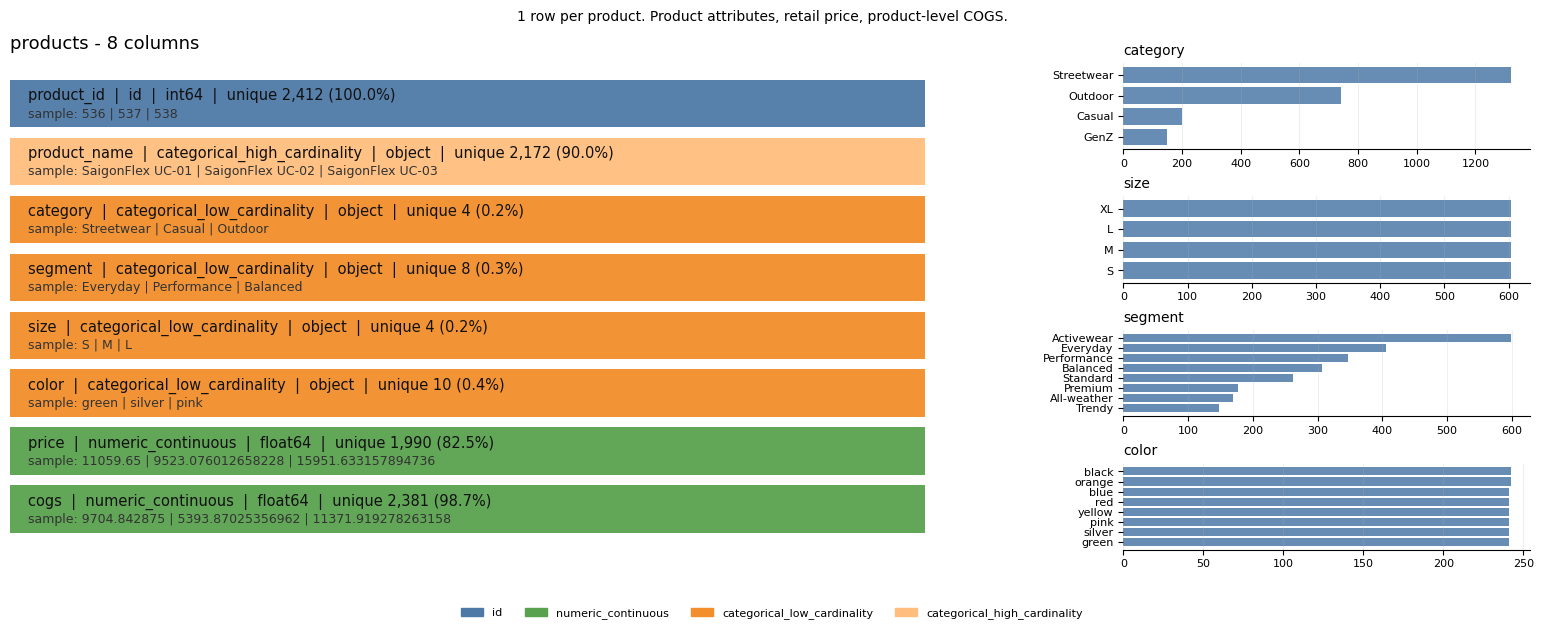

In [12]:
plot_core_table_profile("products", column_profile_summary)


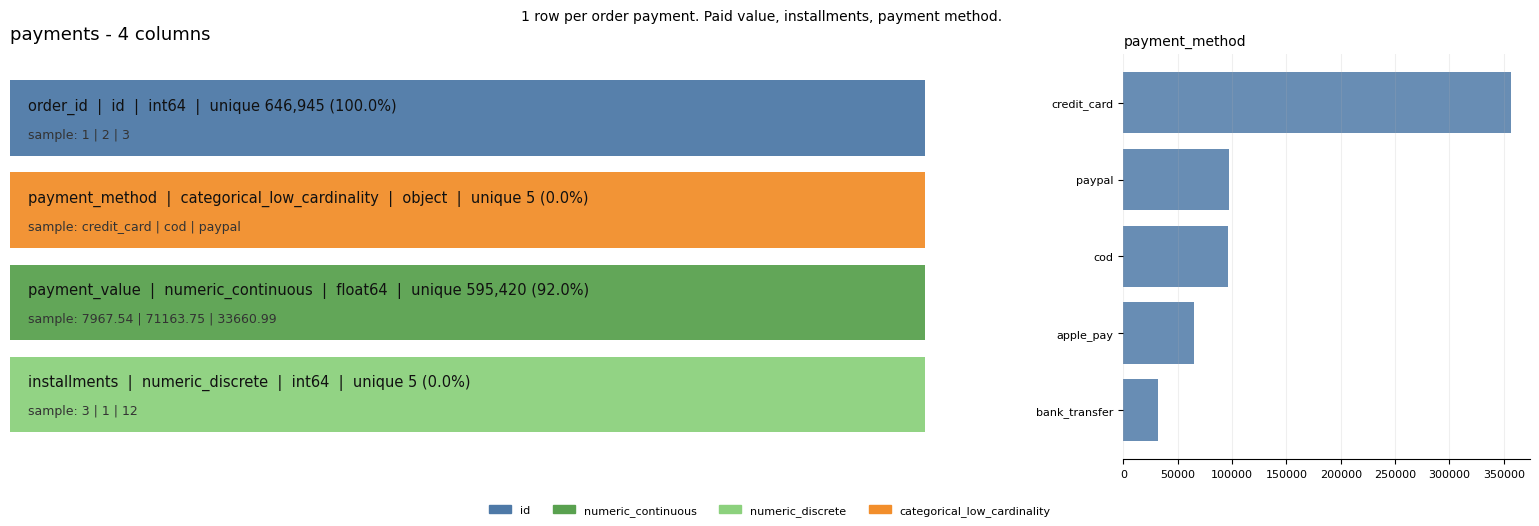

In [13]:
plot_core_table_profile("payments", column_profile_summary)


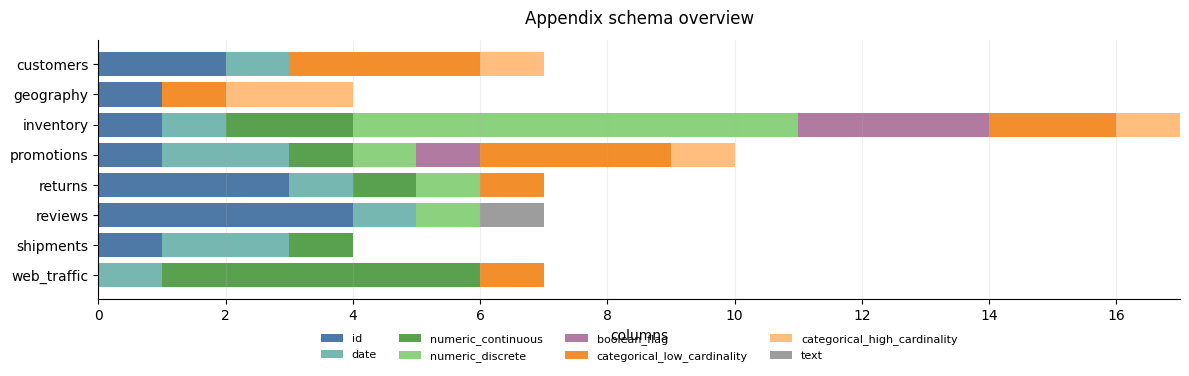

In [14]:
plot_appendix_schema_overview(column_profile_summary)


## 2. Missing values

In [15]:
missing_profile = build_missing_profile(files)
missing_summary = build_missing_summary(files, only_missing=True)


In [16]:
display_table(
    missing_summary,
    caption="missing_summary - columns with missing values",
    formatters={"missing_count": "{:,}", "missing_pct": "{:.2f}%"},
)


,table_name,column,missing_count,missing_pct,interpretation,action
0,order_items,promo_id_2,"714,463",99.97%,Business expected - second stacked promotion is rarely used.,Keep as missing; create a has_second_promo flag if needed.
1,promotions,applicable_category,40,80.00%,Business expected - promotion appears to apply to all categories.,Treat missing as 'ALL_CATEGORIES' for promo eligibility analysis.
2,order_items,promo_id,"438,353",61.34%,Business expected - order line did not use a primary promotion.,Keep as missing or fill with 'NO_PROMO' only for modeling/reporting labels.


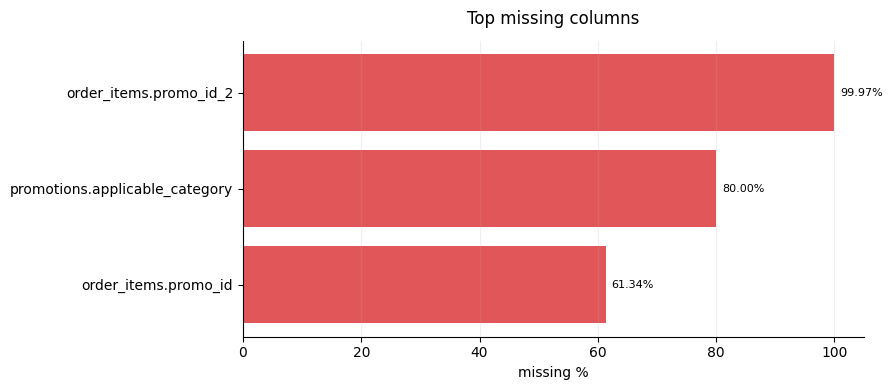

In [17]:
plot_missing_columns(missing_summary)

### Missing value notes

- Dữ liệu gần như không bị thiếu hay trống. 
- Có 3 phần chưa giá trị null là promo_id, promo_id_2 và applicable_category thì đây đều mang đúng ý nghĩa, không phải do lỗi.

## 3. Date range and time consistency

In [18]:
date_range_summary = build_date_range_summary(DATE_RANGE_CHECKS)
time_logic_issues = build_time_logic_issues()
date_continuity_summary = build_date_continuity_summary(date_range_summary)
forecast_availability_table = build_forecast_availability_table()


In [19]:
display_table(
    date_range_summary,
    caption="date_range_summary - required output",
    formatters={
        "min_date": lambda value: "" if pd.isna(value) else value.strftime("%Y-%m-%d"),
        "max_date": lambda value: "" if pd.isna(value) else value.strftime("%Y-%m-%d"),
        "unique_dates": "{:,}",
        "missing_or_invalid": "{:,}",
    },
)


,table_name,date_column,min_date,max_date,unique_dates,missing_or_invalid
0,customers,signup_date,2012-01-17,2022-12-31,"3,941",0
1,orders,order_date,2012-07-04,2022-12-31,"3,833",0
2,sales,Date,2012-07-04,2022-12-31,"3,833",0
3,shipments,ship_date,2012-07-04,2022-12-29,"3,831",0
4,shipments,delivery_date,2012-07-06,2022-12-31,"3,831",0
5,reviews,review_date,2012-07-10,2022-12-31,"3,825",0
6,returns,return_date,2012-07-11,2022-12-31,"3,806",0
7,inventory,snapshot_date,2012-07-31,2022-12-31,126,0
8,web_traffic,date,2013-01-01,2022-12-31,"3,652",0
9,promotions,start_date,2013-01-31,2022-11-18,50,0


In [20]:
display_table(
    time_logic_issues,
    caption="time_logic_issues - required output",
    formatters={
        "issue_count": "{:,}",
        "issue_pct": "{:.4f}%",
    },
)


,rule,violation_condition,issue_count,issue_pct,sample_rows,severity
0,signup_date <= order_date,signup_date > order_date,"477,453",73.8012%,"[{'order_id': 1, 'customer_id': 58578, 'signup_date': '2020-06-06', 'order_date': '2012-07-04'}, {'order_id': 2, 'customer_id': 58621, 'signup_date': '2021-11-03', 'order_date': '2012-07-04'}, {'order_id': 3, 'customer_id': 58811, 'signup_date': '2020-09-18', 'order_date': '2012-07-04'}]",High
1,order_date <= ship_date,order_date > ship_date,0,0.0000%,,OK
2,ship_date <= delivery_date,ship_date > delivery_date,0,0.0000%,,OK
3,order_date <= return_date,order_date > return_date,0,0.0000%,,OK
4,order_date <= review_date,order_date > review_date,0,0.0000%,,OK
5,start_date <= end_date,start_date > end_date,0,0.0000%,,OK


In [21]:
display_table(
    date_continuity_summary,
    caption="Date continuity checks",
    formatters={
        "expected_calendar_days": "{:,}",
        "unique_dates": "{:,}",
        "missing_calendar_days": "{:,}",
    },
)


,table_name,date_column,expected_calendar_days,unique_dates,missing_calendar_days,is_continuous_daily
0,customers,signup_date,"4,002","3,941",61,False
1,orders,order_date,"3,833","3,833",0,True
2,sales,Date,"3,833","3,833",0,True
3,shipments,ship_date,"3,831","3,831",0,True
4,shipments,delivery_date,"3,831","3,831",0,True
5,reviews,review_date,"3,827","3,825",2,False
6,returns,return_date,"3,826","3,806",20,False
7,inventory,snapshot_date,"3,806",126,"3,680",False
8,web_traffic,date,"3,652","3,652",0,True
9,promotions,start_date,"3,579",50,"3,529",False


In [22]:
display_table(
    forecast_availability_table,
    caption="Forecast availability notes",
)


,feature,forecast_note
0,sales.Date,Known before forecast as calendar date.
1,orders.order_date,"Known only after order occurs; use historical lags, not future orders."
2,customers.signup_date,Known for existing customers; future signups are not known.
3,shipments.ship_date,Known only after fulfillment; leakage for same-day future forecast.
4,shipments.delivery_date,Known after delivery; leakage for future forecast.
5,returns.return_date,Known after return; leakage for future forecast.
6,reviews.review_date,Known after review; leakage for future forecast.
7,inventory.snapshot_date,Known only for historical snapshots unless future inventory plan is provided.
8,web_traffic.date,"Known as calendar date, but traffic metrics are only known after the day."
9,promotions.start_date,Can be known before forecast if promotion calendar is planned.


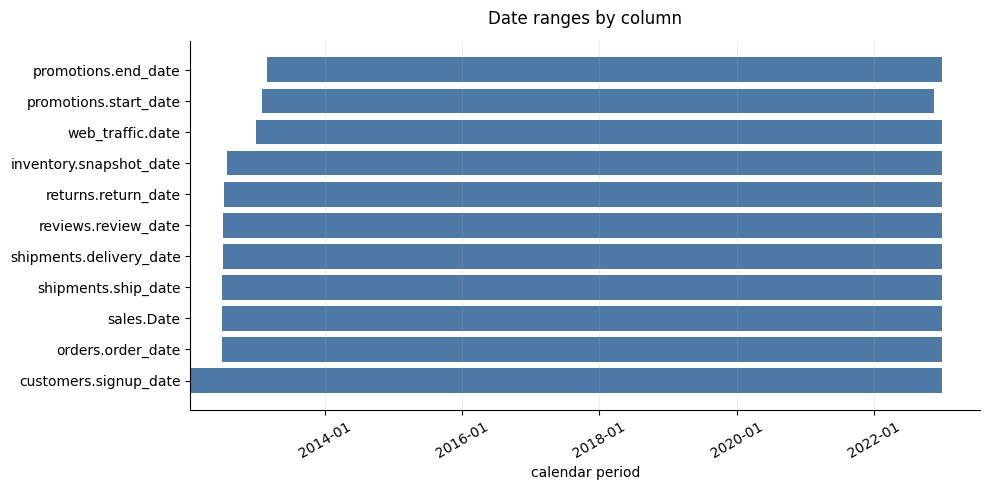

In [23]:
plot_date_ranges(date_range_summary)


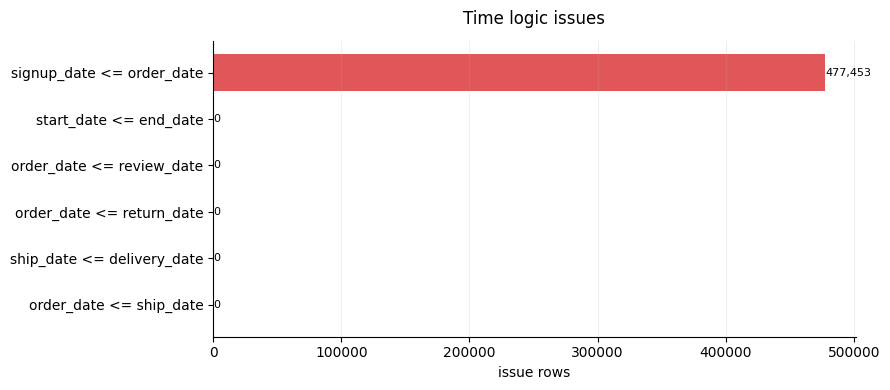

In [24]:
plot_time_logic_issues(time_logic_issues)


## 4. Duplicate and primary key checks

In [25]:
duplicate_key_summary = build_duplicate_key_summary(
    PRIMARY_KEY_CHECKS,
    CANDIDATE_KEY_CHECKS,
)
duplicate_key_examples = build_duplicate_key_examples(
    "order_items",
    CANDIDATE_KEY_CHECKS["order_items"],
)


In [26]:
display_table(
    duplicate_key_summary,
    caption="duplicate_key_summary - primary and candidate key checks",
    formatters={
        "rows": "{:,}",
        "unique_keys": "{:,}",
        "duplicate_rows": "{:,}",
    },
)


,table_name,key_columns,rows,unique_keys,duplicate_rows,severity,note
0,order_items,"order_id, product_id","714,669","714,653",16,Medium,order_id + product_id is not unique. This suggests the table grain is more detailed than this candidate key; aggregate first or add a line-level key before joining.
1,customers,customer_id,"121,930","121,930",0,OK,customer_id is unique; joins at this key should not multiply rows.
2,geography,zip,"39,948","39,948",0,OK,zip is unique; joins at this key should not multiply rows.
3,inventory,"snapshot_date, product_id","60,247","60,247",0,OK,snapshot_date + product_id is unique; joins at this key should not multiply rows.
4,orders,order_id,"646,945","646,945",0,OK,order_id is unique; joins at this key should not multiply rows.
5,payments,order_id,"646,945","646,945",0,OK,order_id is unique; joins at this key should not multiply rows.
6,products,product_id,"2,412","2,412",0,OK,product_id is unique; joins at this key should not multiply rows.
7,promotions,promo_id,50,50,0,OK,promo_id is unique; joins at this key should not multiply rows.
8,returns,return_id,"39,939","39,939",0,OK,return_id is unique; joins at this key should not multiply rows.
9,reviews,review_id,"113,551","113,551",0,OK,review_id is unique; joins at this key should not multiply rows.


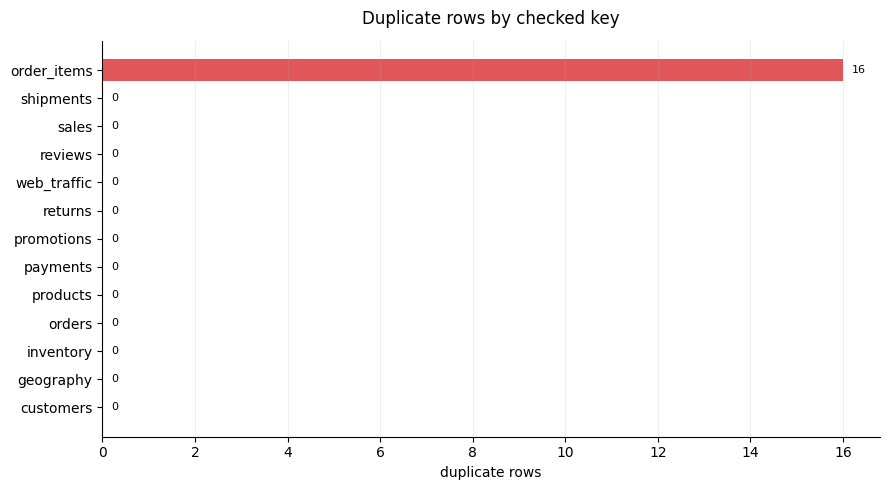

In [27]:
plot_duplicate_rows(duplicate_key_summary)

In [28]:
display_table(
    duplicate_key_examples,
    caption="Example duplicate rows for order_items candidate key",
)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,14280,976,1,4019.470000,0.000000,nan,nan
1,14280,976,2,3937.990000,0.000000,nan,nan
2,113379,786,6,694.340000,0.000000,nan,nan
3,113379,786,1,699.370000,0.000000,nan,nan
4,215525,1859,5,1896.110000,0.000000,nan,nan
5,215525,1859,5,1897.200000,0.000000,nan,nan
6,216740,791,8,793.100000,0.000000,nan,nan
7,216740,791,5,825.520000,0.000000,nan,nan
8,243342,777,7,1181.170000,1653.640000,PROMO-0010,nan
9,243342,777,5,1147.210000,1147.210000,PROMO-0010,nan


### Duplicate key notes

- Khong co duplicate tren cac primary key duoc yeu cau kiem tra.
- Candidate key `order_items.order_id + product_id` co duplicate, nen `order_items` khong that su unique o grain nay.
- Cac dong duplicate trong `order_items` co quantity/unit_price/discount khac nhau, vi vay khong nen drop may moc.
- Khi join `order_items` voi bang khac, nen join qua `order_id` voi bang order-level, hoac aggregate theo `order_id + product_id` neu can product-level trong order.

## 4B. Relationship checks

In [29]:
relationship_checks = build_relationship_checks(RELATIONSHIPS)


In [30]:
display_table(
    relationship_checks,
    caption="relationship_checks - foreign key and parent key quality",
    formatters={
        "child_rows": "{:,}",
        "child_non_null_rows": "{:,}",
        "parent_rows": "{:,}",
        "parent_unique_keys": "{:,}",
        "parent_duplicate_rows": "{:,}",
        "orphan_rows": "{:,}",
        "orphan_pct": "{:.4f}%",
    },
)


,child_table,child_key,parent_table,parent_key,relationship,child_rows,child_non_null_rows,parent_rows,parent_unique_keys,parent_duplicate_rows,orphan_rows,orphan_pct,severity,note
0,inventory,product_id,products,product_id,many-to-one,"60,247","60,247","2,412","2,412",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
1,order_items,order_id,orders,order_id,many-to-one,"714,669","714,669","646,945","646,945",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
2,order_items,product_id,products,product_id,many-to-one,"714,669","714,669","2,412","2,412",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
3,order_items,promo_id,promotions,promo_id,many-to-zero-or-one,"714,669","276,316",50,50,0,0,0.0000%,OK,No orphan keys among non-null optional relationship values.
4,order_items,promo_id_2,promotions,promo_id,many-to-zero-or-one,"714,669",206,50,50,0,0,0.0000%,OK,No orphan keys among non-null optional relationship values.
5,orders,customer_id,customers,customer_id,many-to-one,"646,945","646,945","121,930","121,930",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
6,orders,zip,geography,zip,many-to-one,"646,945","646,945","39,948","39,948",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
7,payments,order_id,orders,order_id,one-to-one,"646,945","646,945","646,945","646,945",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
8,returns,order_id,orders,order_id,many-to-one,"39,939","39,939","646,945","646,945",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.
9,returns,product_id,products,product_id,many-to-one,"39,939","39,939","2,412","2,412",0,0,0.0000%,OK,No orphan keys; relationship is join-safe at checked key.


g:\ds\task_27_05_2026\datathon_quality.py:1695: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


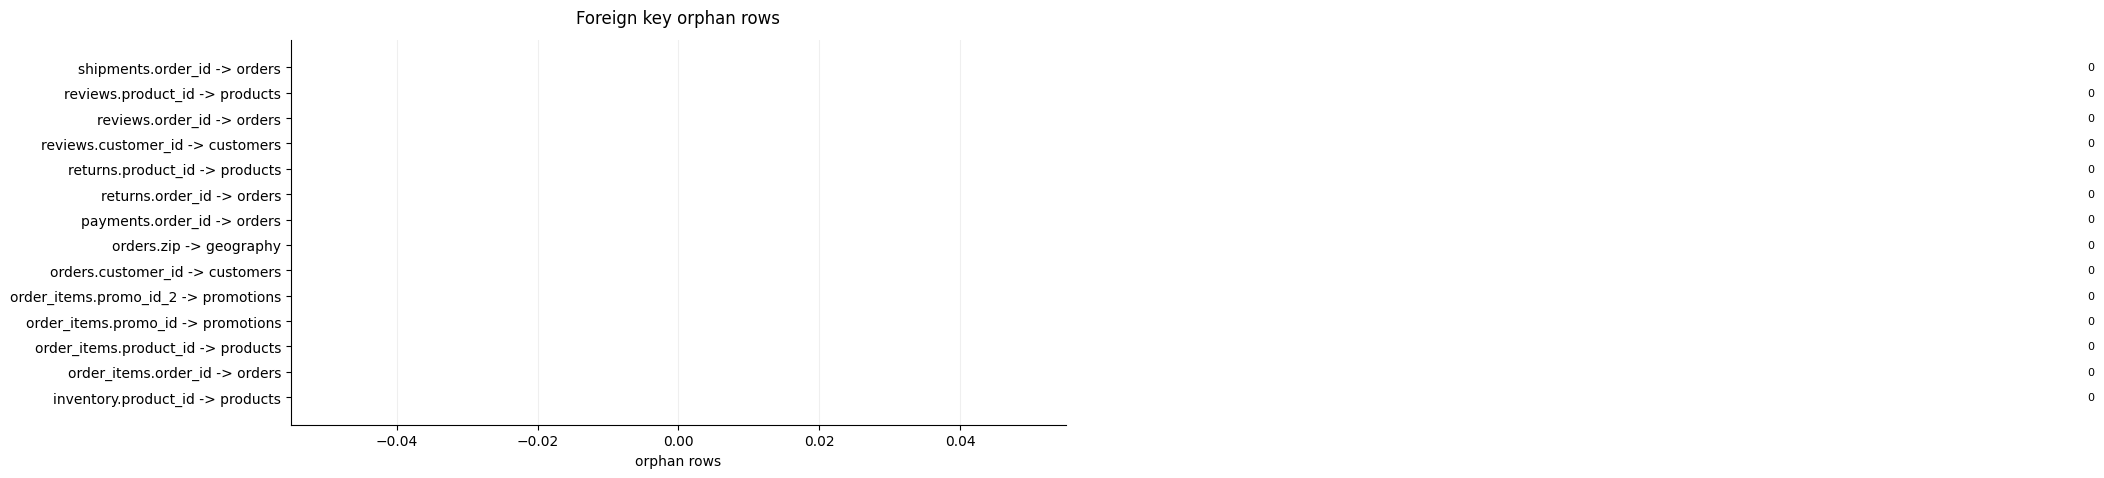

In [31]:
plot_relationship_orphans(relationship_checks)


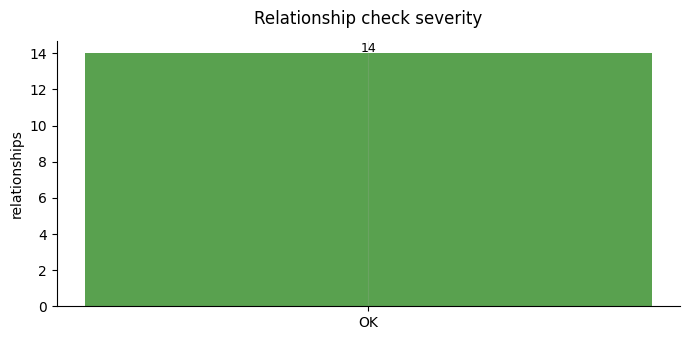

In [32]:
plot_relationship_status(relationship_checks)


### Relationship check notes

- `orphan_rows = 0` nghia la cac key con co the map sang bang cha.
- `parent_duplicate_rows = 0` nghia la join theo parent key khong lam nhan dong do duplicate parent.
- Cac relationship nullable nhu promo chi kiem orphan tren non-null values.

## 5. Business rule checks

In [33]:
business_rule_issues = build_business_rule_issues(BUSINESS_RULES)
business_rule_examples = build_business_rule_examples(BUSINESS_RULES)

In [34]:
display_table(
    business_rule_issues,
    caption="business_rule_issues - required output",
    formatters={
        "issue_count": "{:,}",
        "issue_pct": "{:.4f}%",
    },
)


,table_name,rule,issue_count,issue_pct,severity,note
0,sales,sales.COGS <= sales.Revenue,382,9.9661%,Medium,"COGS exceeds Revenue. This may be a real negative-margin day, not automatically a data error."
1,inventory,inventory.fill_rate between 0 and 1,0,0.0000%,OK,All fill_rate values are between 0 and 1.
2,inventory,inventory.sell_through_rate between 0 and 1,0,0.0000%,OK,All sell_through_rate values are between 0 and 1.
3,inventory,inventory.stock_on_hand >= 0,0,0.0000%,OK,No negative stock_on_hand values found.
4,inventory,inventory.stockout_days >= 0,0,0.0000%,OK,No negative stockout_days values found.
5,inventory,inventory.units_received >= 0,0,0.0000%,OK,No negative units_received values found.
6,inventory,inventory.units_sold >= 0,0,0.0000%,OK,No negative units_sold values found.
7,order_items,order_items.discount_amount <= quantity * unit_price,0,0.0000%,OK,No discount exceeds gross line value.
8,order_items,order_items.discount_amount >= 0,0,0.0000%,OK,No negative discounts found.
9,order_items,order_items.quantity > 0,0,0.0000%,OK,All order item quantities are positive.


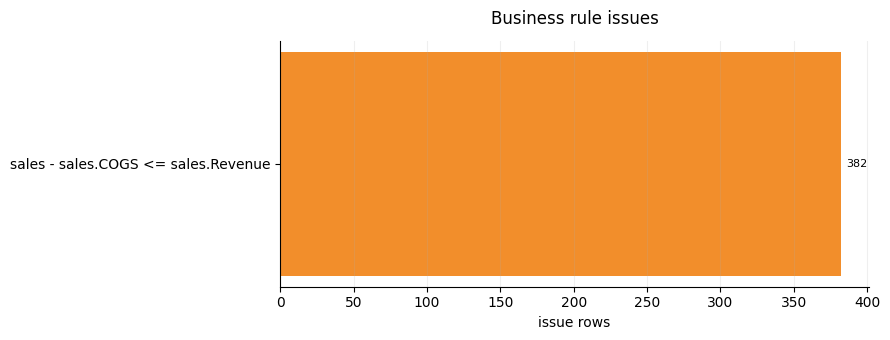

In [35]:
plot_business_rule_issues(business_rule_issues)


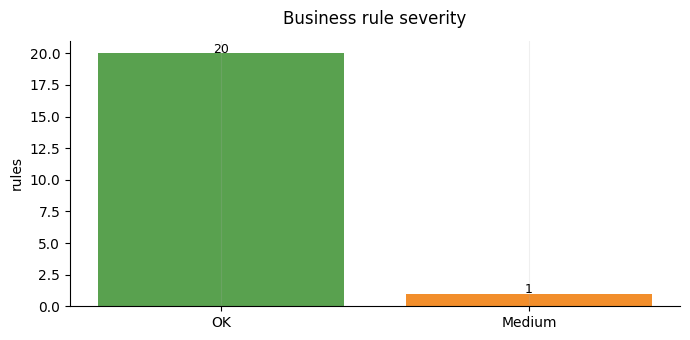

In [36]:
plot_business_rule_severity(business_rule_issues)


In [37]:
display_table(
    business_rule_examples,
    caption="Example rows for failed business rules",
)


,table_name,rule,Date,Revenue,COGS
0,sales,sales.COGS <= sales.Revenue,2013-07-31,10104475.360000,10851542.120000
1,sales,sales.COGS <= sales.Revenue,2013-08-01,10998208.400000,12167214.070000
2,sales,sales.COGS <= sales.Revenue,2013-08-02,7422715.150000,9601836.110000
3,sales,sales.COGS <= sales.Revenue,2013-08-03,5599602.670000,7786528.350000
4,sales,sales.COGS <= sales.Revenue,2013-08-04,5021938.290000,7089757.760000


### Business rule notes

- Khong thay gia tri am/bat thuong trong price, COGS, quantity, unit_price, discount, payment, shipping fee, refund, rating, va inventory metrics.
- Khong co discount nao lon hon `quantity * unit_price`.
- Khong co rating ngoai khoang 1-5.
- Co ngay `sales.COGS > sales.Revenue`; day nen duoc xem la ngay gross margin am can phan tich them, khong nen tu dong coi la data error.

## 6. Order lifecycle and status consistency

Muc tieu cua phan nay:
- Kiem tra `order_status` co nhat quan voi payment, shipment, return va review khong.
- Day la data quality chung, chua ket luan nen tinh revenue theo status nao.
- Tach issue lifecycle ra khoi business rules de de doc va de report.

Output chinh:
- `order_status_summary`
- `payment_order_check`
- `lifecycle_consistency_issues`

In [38]:
order_lifecycle = build_order_lifecycle_table()
order_status_summary = build_order_status_summary(order_lifecycle)
payment_order_check = build_payment_order_check()
lifecycle_consistency_issues = build_lifecycle_consistency_issues(order_lifecycle)

order_lifecycle_summary = order_status_summary
order_lifecycle_issues = lifecycle_consistency_issues


g:\ds\task_27_05_2026\datathon_quality.py:2116: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lifecycle[column] = lifecycle[column].fillna(False).astype(bool)
g:\ds\task_27_05_2026\datathon_quality.py:2116: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lifecycle[column] = lifecycle[column].fillna(False).astype(bool)
g:\ds\task_27_05_2026\datathon_quality.py:2116: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the futur

In [39]:
display_table(
    order_status_summary,
    caption="order_status_summary",
    formatters={
        "orders": "{:,}",
        "order_pct": "{:.2f}%",
        "has_payment_pct": "{:.2f}%",
        "has_shipment_pct": "{:.2f}%",
        "has_return_pct": "{:.2f}%",
        "has_review_pct": "{:.2f}%",
        "delivery_date_missing_pct": "{:.2f}%",
    },
)


,order_status,orders,has_payment_pct,has_shipment_pct,has_return_pct,has_review_pct,delivery_date_missing_pct,order_pct
0,delivered,"516,716",100.00%,99.90%,0.00%,21.55%,0.10%,79.87%
1,cancelled,"59,462",100.00%,0.00%,0.00%,0.00%,100.00%,9.19%
2,returned,"36,142",100.00%,99.92%,99.78%,0.00%,0.08%,5.59%
3,shipped,"13,773",100.00%,99.92%,0.00%,0.00%,0.08%,2.13%
4,paid,"13,577",100.00%,0.00%,0.00%,0.00%,100.00%,2.10%
5,created,"7,275",100.00%,0.00%,0.00%,0.00%,100.00%,1.12%


In [40]:
display_table(
    payment_order_check,
    caption="Payment vs order 1:1 checks",
    formatters={"count": "{:,}"},
)


,check,count,severity,note
0,orders without payment,0,OK,Every order should have one payment record.
1,payments without order,0,OK,Every payment should map to an order.
2,duplicate payment order_id,0,OK,Payment is expected to be 1:1 with orders.


In [41]:
display_table(
    lifecycle_consistency_issues,
    caption="lifecycle_consistency_issues",
    formatters={
        "issue_count": "{:,}",
        "issue_pct": "{:.4f}%",
    },
)


,rule,issue_count,issue_pct,sample_rows,severity,note
0,delivered orders should have delivery_date,524,0.0810%,"[{'order_id': 832884, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 832955, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 832978, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}]",High,Delivered order has missing delivery_date.
1,delivered orders should have shipment,524,0.0810%,"[{'order_id': 832884, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 832955, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 832978, 'order_status': 'delivered', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}]",High,Delivered order has no shipment record.
2,returned orders should have return record,80,0.0124%,"[{'order_id': 831459, 'order_status': 'returned', 'has_payment': True, 'has_shipment': True, 'has_return': False, 'has_review': False, 'ship_date': '2022-12-07', 'delivery_date': '2022-12-12'}, {'order_id': 831517, 'order_status': 'returned', 'has_payment': True, 'has_shipment': True, 'has_return': False, 'has_review': False, 'ship_date': '2022-12-08', 'delivery_date': '2022-12-13'}, {'order_id': 831579, 'order_status': 'returned', 'has_payment': True, 'has_shipment': True, 'has_return': False, 'has_review': False, 'ship_date': '2022-12-11', 'delivery_date': '2022-12-13'}]",High,Returned status exists without return table record.
3,returned orders should have shipment,29,0.0045%,"[{'order_id': 833177, 'order_status': 'returned', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 833248, 'order_status': 'returned', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 833267, 'order_status': 'returned', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}]",High,Returned order has no shipment record.
4,shipped orders should have shipment,11,0.0017%,"[{'order_id': 832929, 'order_status': 'shipped', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 833342, 'order_status': 'shipped', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}, {'order_id': 833376, 'order_status': 'shipped', 'has_payment': True, 'has_shipment': False, 'has_return': False, 'has_review': False, 'ship_date': nan, 'delivery_date': nan}]",High,Shipped order has no shipment record.
5,cancelled orders should not have shipment,0,0.0000%,,OK,No cancelled order has shipment.
6,created/paid orders should not have delivery_date,0,0.0000%,,OK,No created/paid order has delivery_date.
7,return should only appear for returned,0,0.0000%,,OK,Return records only appear in returned status.
8,review should only appear for delivered/returned,0,0.0000%,,OK,Review records only appear in delivered/returned statuses.
9,shipment should only appear for shipped/delivered/returned,0,0.0000%,,OK,Shipment only appears in shipped/delivered/returned statuses.


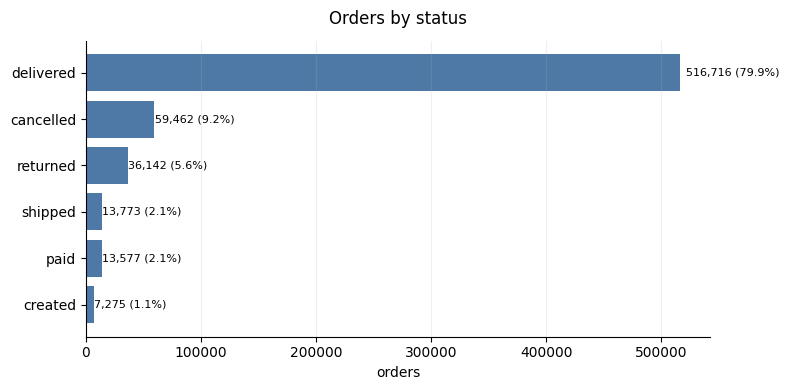

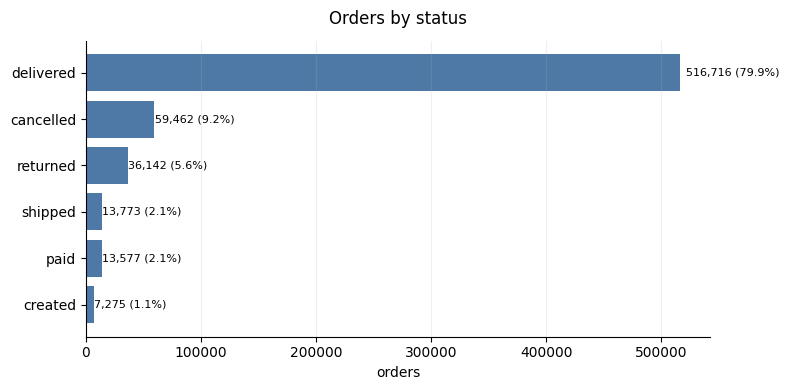

In [42]:
plot_order_status_distribution(order_status_summary)


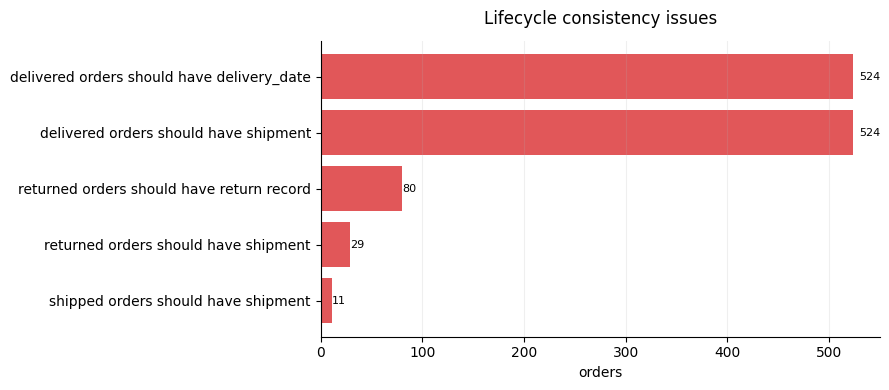

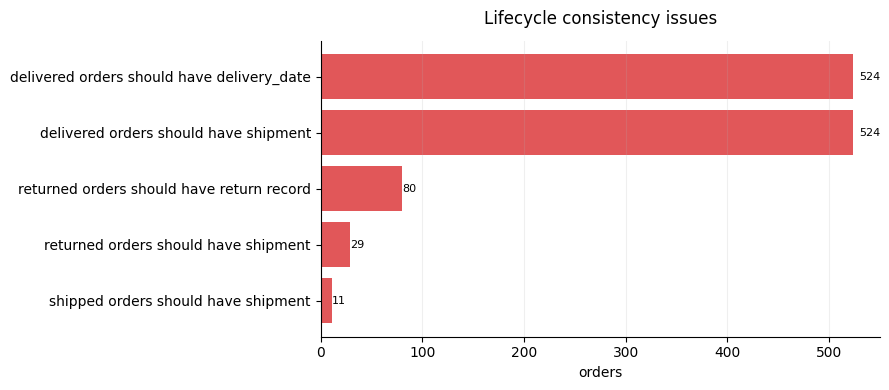

In [43]:
plot_lifecycle_issue_counts(lifecycle_consistency_issues)


### Order lifecycle notes

- `payments` is 1:1 with `orders`: no missing payment, no orphan payment, no duplicate payment order_id.
- Shipment appears only in logical statuses: `shipped`, `delivered`, `returned`.
- Return records appear only for `returned` status.
- Review records appear only for `delivered`/`returned`; in this data, reviews are present for delivered orders and not for returned orders.
- Main consistency issues are small but important: some `delivered` orders miss `delivery_date`, some `returned` orders miss return/shipment records, and a few `shipped` orders miss shipment records.

## 7. Sales vs transaction consistency

In [44]:
sales_transaction_consistency, sales_transaction_daily = build_sales_transaction_consistency()
sales_transaction_issues = build_sales_transaction_issues(
    sales_transaction_consistency,
    sales_transaction_daily,
)


In [45]:
display_table(
    sales_transaction_consistency,
    caption="sales_transaction_consistency - required output",
    formatters={
        "MAE": "{:,.2f}",
        "median_AE": "{:,.2f}",
        "MPE": "{:.4f}%",
        "correlation": "{:.6f}",
        "max_AE": "{:,.2f}",
    },
)


,status_filter,compared_metric,MAE,median_AE,MPE,correlation,max_AE,note
0,all orders,sales.COGS vs calculated_cogs,0.00,0.00,-0.0000%,1.000000,0.00,Exact reconciliation; sales.csv appears to use this all-order definition.
1,non-cancelled orders,sales.COGS vs calculated_cogs,"341,074.17","290,364.97",-9.2162%,0.998391,"1,767,359.86",Status-filtered subset is expected to differ from total sales.csv.
2,paid/shipped/delivered/returned,sales.COGS vs calculated_cogs,"384,191.97","328,374.20",-10.4510%,0.998118,"1,963,952.83",Status-filtered subset is expected to differ from total sales.csv.
3,delivered + returned,sales.COGS vs calculated_cogs,"541,740.18","467,886.99",-14.8600%,0.997121,"2,514,834.58",Status-filtered subset is expected to differ from total sales.csv.
4,delivered only,sales.COGS vs calculated_cogs,"745,900.50","648,659.74",-20.3995%,0.995897,"3,425,037.24",Status-filtered subset is expected to differ from total sales.csv.
5,all orders,sales.Revenue vs gross_revenue,0.00,0.00,-0.0000%,1.000000,0.00,Exact reconciliation; sales.csv appears to use this all-order definition.
6,non-cancelled orders,sales.Revenue vs gross_revenue,"395,484.22","336,071.24",-9.2064%,0.998496,"1,890,367.64",Status-filtered subset is expected to differ from total sales.csv.
7,paid/shipped/delivered/returned,sales.Revenue vs gross_revenue,"445,223.93","380,140.00",-10.4351%,0.998252,"2,134,702.29",Status-filtered subset is expected to differ from total sales.csv.
8,delivered + returned,sales.Revenue vs gross_revenue,"627,665.59","529,406.21",-14.8466%,0.997334,"2,992,761.69",Status-filtered subset is expected to differ from total sales.csv.
9,delivered only,sales.Revenue vs gross_revenue,"864,436.53","743,276.86",-20.3825%,0.996193,"4,219,735.16",Status-filtered subset is expected to differ from total sales.csv.


In [46]:
display_table(
    sales_transaction_issues,
    caption="sales_transaction_issues - required output",
    formatters={"affected_dates": "{:,}"},
)


,issue,affected_dates,severity,decision,reason
0,sales.Revenue vs all-order gross_revenue mismatch,0,OK,Use sales.Revenue as all-order gross revenue baseline.,sales.Revenue reconciles exactly to quantity * unit_price across all orders.
1,sales.COGS vs all-order calculated_cogs mismatch,0,OK,Use sales.COGS as all-order COGS baseline.,sales.COGS reconciles to quantity * products.cogs within rounding tolerance.
2,sales.Revenue differs from net_revenue,"1,707",Low,Document definition difference.,"sales.csv stores gross revenue before discount, while net_revenue subtracts discount_amount."
3,sales.Revenue differs from payment_value,"1,707",Low,Do not use payment_value as direct replacement for sales.Revenue.,"payment_value follows discounted/net order value in this data, not gross Revenue."
4,status-filtered transaction subsets differ from sales.csv totals,4,Low,Treat as expected unless analysis intentionally filters statuses.,"sales.csv appears to be generated from all orders, so delivered-only/non-cancelled subsets will not match totals."


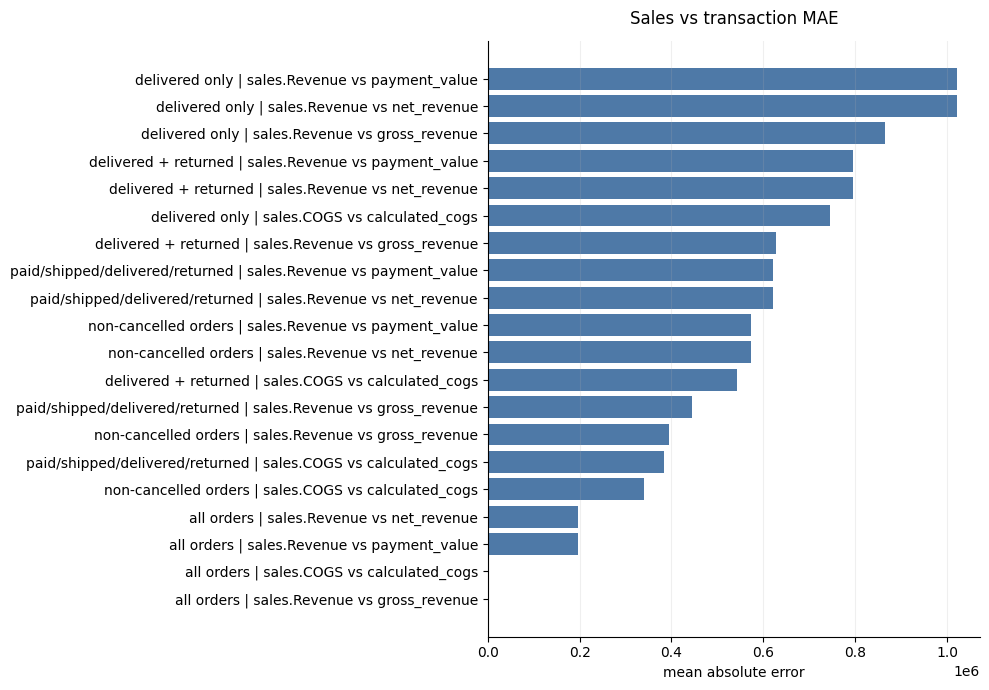

In [47]:
plot_sales_transaction_mae(sales_transaction_consistency)


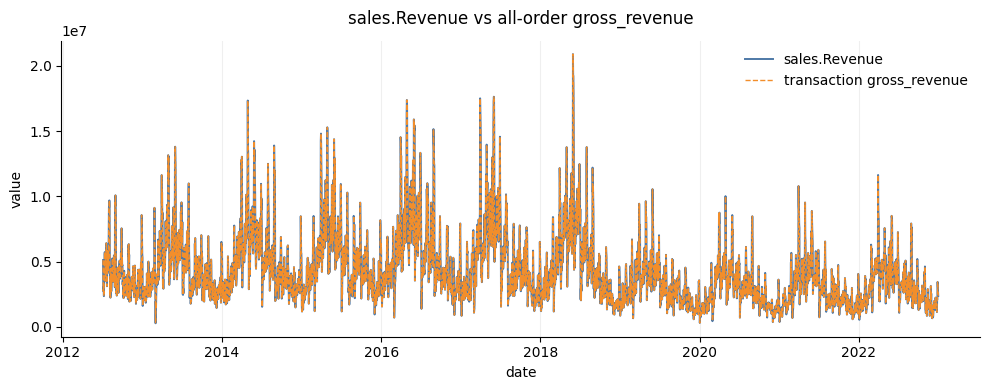

In [48]:
plot_sales_vs_gross_revenue(sales_transaction_daily)


### Sales vs transaction notes

- `sales.Revenue` khop voi `gross_revenue = quantity * unit_price` tren **all orders**.
- `sales.COGS` khop voi `calculated_cogs = quantity * products.cogs` tren **all orders**.
- `sales.Revenue` khong phai `net_revenue` hoac `payment_value`; sai lech xuat hien o cac ngay co discount.
- Khi loc theo status nhu delivered-only hay non-cancelled, transaction totals khong khop `sales.csv` vi `sales.csv` co ve la all-order gross view.
- Can ghi chu trong report: `sales.csv` duoc tao theo gross revenue va all orders, khong phai net/payment/status-filtered revenue.

## 8. Outlier checks at data quality level

Muc tieu cua phan nay:
- Flag gia tri cuc doan de kiem tra chat luong du lieu.
- Khong mac dinh outlier la loi va khong dien giai y nghia kinh doanh o buoc nay.
- Ket hop rule-based invalid checks voi IQR outlier checks.

Output chinh:
- `outlier_quality_summary`

In [49]:
outlier_quality_summary = build_outlier_quality_summary(OUTLIER_TARGETS)


In [50]:
display_table(
    outlier_quality_summary,
    caption="outlier_quality_summary - required output",
    formatters={
        "lower_bound": "{:,.4f}",
        "upper_bound": "{:,.4f}",
        "outlier_count": "{:,}",
        "outlier_pct": "{:.4f}%",
        "min": "{:,.4f}",
        "p1": "{:,.4f}",
        "median": "{:,.4f}",
        "p99": "{:,.4f}",
        "max": "{:,.4f}",
    },
)


,table_name,column,method,lower_bound,upper_bound,outlier_count,outlier_pct,min,p1,median,p99,max,bottom_5,top_5,decision,note
0,order_items,discount_amount,rule + IQR,"-1,451.4450","2,419.0750","105,767",14.7994%,0.0000,0.0000,0.0000,"11,041.1488","35,235.4700","[0.0, 0.0, 0.0, 0.0, 0.0]","[35235.47, 31279.62, 30591.81, 30531.31, 30212.41]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
1,shipments,shipping_fee,rule + IQR,-1.7250,5.1950,"76,050",13.4348%,0.0000,0.0400,1.7300,31.2900,32.0000,"[0.0, 0.0, 0.0, 0.0, 0.0]","[32.0, 32.0, 32.0, 32.0, 32.0]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
2,payments,payment_value,rule + IQR,"-31,356.8750","72,744.2850","30,219",4.6710%,389.7400,"1,052.6688","17,229.4400","98,075.7456","331,570.4000","[389.74, 428.2, 428.34, 428.94, 429.07]","[331570.4, 271911.67, 269154.22, 250034.88, 246463.2]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
3,order_items,unit_price,rule + IQR,"-6,143.4150","15,324.0650","8,623",1.2066%,392.5700,627.8700,"4,257.7700","15,778.4812","43,056.0000","[392.57, 431.87, 432.47, 442.89, 444.23]","[43056.0, 42937.31, 42268.78, 41672.48, 41446.3]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
4,inventory,stock_on_hand,rule + IQR,-277.5000,502.5000,"6,432",10.6761%,3.0000,3.0000,62.0000,"1,525.0800","2,673.0000","[3, 3, 3, 3, 3]","[2673, 2657, 2653, 2648, 2645]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
5,inventory,units_sold,rule + IQR,-19.0000,37.0000,"6,388",10.6030%,1.0000,1.0000,6.0000,135.0000,670.0000,"[1, 1, 1, 1, 1]","[670, 670, 659, 659, 580]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
6,returns,refund_amount,rule + IQR,"-16,389.4975","36,844.8825","2,778",6.9556%,458.8100,635.2144,"7,888.8800","66,677.2844","160,937.9400","[458.81, 478.76, 482.21, 487.67, 490.62]","[160937.94, 140451.45, 138122.19, 133531.2, 128159.74]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
7,inventory,sell_through_rate,rule + IQR,-0.2519,0.5321,"1,284",2.1312%,0.0004,0.0025,0.1111,0.6000,0.8531,"[0.0004, 0.0005, 0.0005, 0.0005, 0.0006]","[0.8531, 0.8438, 0.8387, 0.8276, 0.8148]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
8,inventory,fill_rate,rule + IQR,0.8333,1.1000,724,1.2017%,0.0667,0.7667,0.9667,1.0000,1.0000,"[0.0667, 0.0667, 0.0667, 0.0667, 0.0667]","[1.0, 1.0, 1.0, 1.0, 1.0]",Flag only,IQR extreme values found; flag for review but do not remove automatically.
9,sales,Revenue,rule + IQR,"-1,848,593.7500","9,670,559.7700",169,4.4091%,"279,813.9400","845,078.7520","3,647,303.9000","13,801,990.0536","20,905,271.3500","[279813.94, 306693.87, 370653.23, 378420.41, 440505.08]","[20905271.35, 19289944.12, 19245165.78, 17639270.88, 17529108.34]",Flag only,IQR extreme values found; flag for review but do not remove automatically.


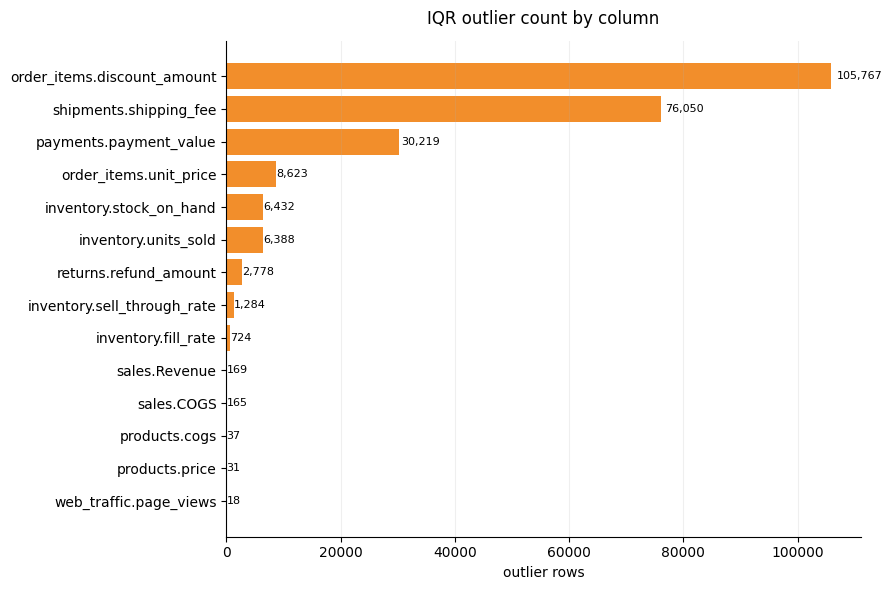

In [51]:
plot_outlier_counts(outlier_quality_summary)


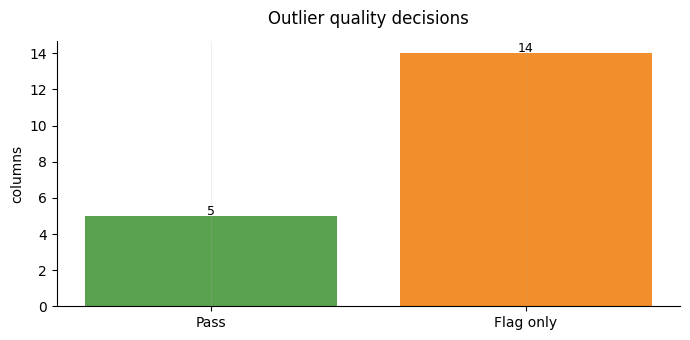

In [52]:
plot_outlier_decisions(outlier_quality_summary)


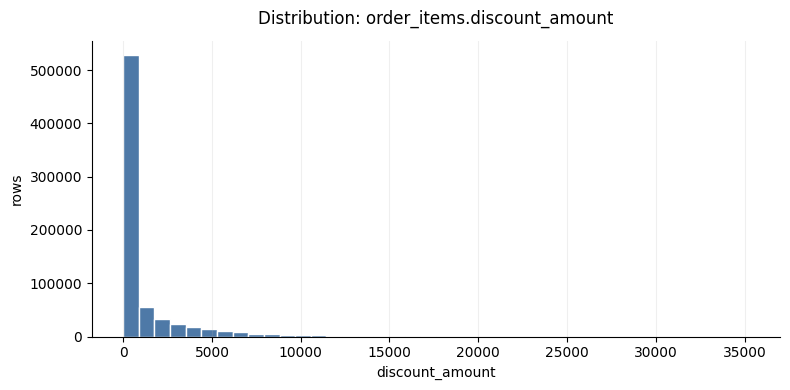

In [53]:
plot_numeric_distribution('order_items', 'discount_amount')


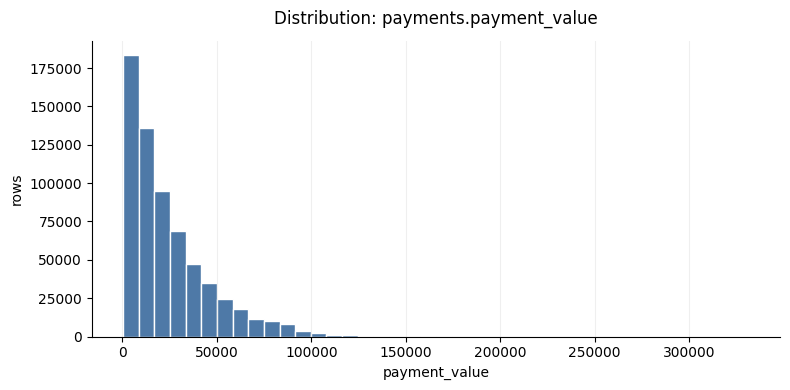

In [54]:
plot_numeric_distribution('payments', 'payment_value')


In [55]:
payment_distribution_diagnostic = build_payment_distribution_diagnostic()
display_table(
    payment_distribution_diagnostic,
    caption="payment_distribution_diagnostic",
    formatters={
        "rows": "{:,}",
        "mean": "{:,.2f}",
        "median": "{:,.2f}",
        "std": "{:,.2f}",
        "skew": "{:.4f}",
        "kurtosis": "{:.4f}",
        "min": "{:,.2f}",
        "p1": "{:,.2f}",
        "p99": "{:,.2f}",
        "max": "{:,.2f}",
    },
)


,metric,rows,mean,median,std,skew,kurtosis,min,p1,p99,max,note
0,payment_value,"646,945","24,238.33","17,229.44","22,378.48",1.6791,3.6882,389.74,"1,052.67","98,075.75","331,570.40",Right-skewed order-level value; not expected to be normal.
1,log1p(payment_value),"646,945",9.65,9.75,1.03,-0.4429,-0.1924,5.97,6.96,11.49,12.71,Much closer to symmetric; payment values behave more like log-normal.


In [56]:
payment_reconciliation_diagnostic = build_payment_reconciliation_diagnostic()
display_table(
    payment_reconciliation_diagnostic,
    caption="payment_reconciliation_diagnostic",
    formatters={
        "affected_orders": "{:,}",
        "max_abs_diff": "{:,.4f}",
        "correlation": "{:.6f}",
    },
)


,check,affected_orders,max_abs_diff,correlation,note
0,payment_value vs net_revenue,0,0.0000,1.000000,payment_value exactly reconciles to sum(quantity * unit_price - discount_amount).
1,payment_value vs gross_revenue,"248,242","37,183.1600",0.994669,difference is discount; payment_value is not gross order value.


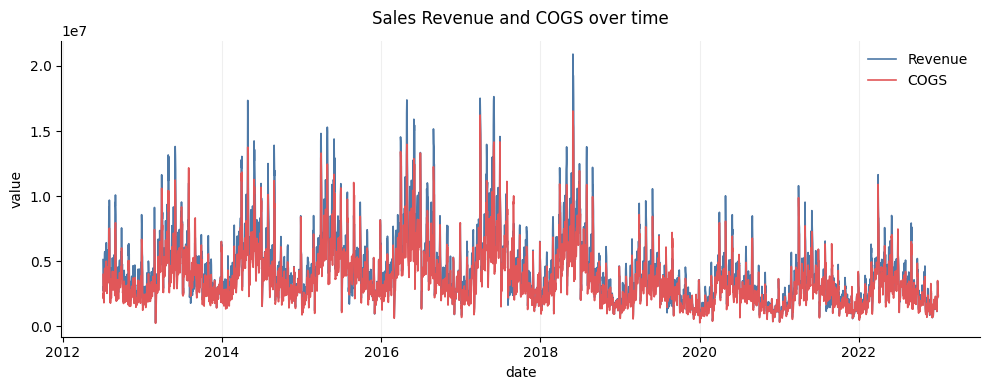

In [ ]:
plot_sales_revenue_cogs_line()


### Outlier data quality notes

- Rule-based invalid checks pass: no non-positive quantity/unit price/price/COGS, no negative discount/payment/refund/shipping fee, no invalid rating/rate values.
- IQR flags exist in heavy-tailed numeric columns such as discount, payment value, shipping fee, refund amount, sales totals, and inventory volumes.
- These are flagged for review only; do not remove automatically before EDA.
- No column currently needs `Fix/exclude` based on the listed invalid-value rules.

## 9. Final data quality issue log

Muc tieu:
- Gom tat ca issue tu cac section data quality vao mot bang duy nhat.
- Gan severity va decision de biet issue nao can xu ly truoc EDA, issue nao chi can flag/report.

Output chinh:
- `data_quality_issue_log`

In [ ]:
data_quality_issue_log = build_data_quality_issue_log(
    dtype_issues=dtype_issues,
    missing_summary=missing_summary,
    duplicate_key_summary=duplicate_key_summary,
    relationship_checks=relationship_checks,
    time_logic_issues=time_logic_issues,
    business_rule_issues=business_rule_issues,
    order_lifecycle_issues=order_lifecycle_issues,
    sales_transaction_issues=sales_transaction_issues,
    outlier_quality_summary=outlier_quality_summary,
)


In [ ]:
display_table(
    data_quality_issue_log,
    caption="data_quality_issue_log - final action table",
    formatters={
        "affected_rows": "{:,}",
        "affected_pct": "{:.4f}%",
    },
)


,issue_id,source_check,table_name,column,issue_type,affected_rows,affected_pct,severity,decision,reason
0,DQ-001,time_logic_issues,multiple,,signup_date <= order_date,"477,453",73.8012%,High,Investigate later,Temporal logic violation found. Review sample_rows in time_logic_issues.
1,DQ-002,order_lifecycle_issues,orders,order_status,delivered orders should have delivery_date,524,0.0810%,High,Investigate later,Delivered order has missing delivery_date.
2,DQ-003,order_lifecycle_issues,orders,order_status,delivered orders should have shipment,524,0.0810%,High,Investigate later,Delivered order has no shipment record.
3,DQ-004,order_lifecycle_issues,orders,order_status,returned orders should have return record,80,0.0124%,High,Investigate later,Returned status exists without return table record.
4,DQ-005,order_lifecycle_issues,orders,order_status,returned orders should have shipment,29,0.0045%,High,Investigate later,Returned order has no shipment record.
5,DQ-006,order_lifecycle_issues,orders,order_status,shipped orders should have shipment,11,0.0017%,High,Investigate later,Shipped order has no shipment record.
6,DQ-007,business_rule_issues,sales,,sales.COGS <= sales.Revenue,382,9.9661%,Medium,Investigate later,"COGS exceeds Revenue. This may be a real negative-margin day, not automatically a data error."
7,DQ-008,duplicate_key_summary,order_items,"order_id, product_id",duplicate_key,16,0.0022%,Medium,Investigate later,order_id + product_id is not unique. This suggests the table grain is more detailed than this candidate key; aggregate first or add a line-level key before joining.
8,DQ-009,missing_summary,order_items,promo_id_2,missing_values,"714,463",99.9700%,Low,Keep as is,Business expected - second stacked promotion is rarely used. Action: Keep as missing; create a has_second_promo flag if needed.
9,DQ-010,missing_summary,order_items,promo_id,missing_values,"438,353",61.3400%,Low,Keep as is,Business expected - order line did not use a primary promotion. Action: Keep as missing or fill with 'NO_PROMO' only for modeling/reporting labels.


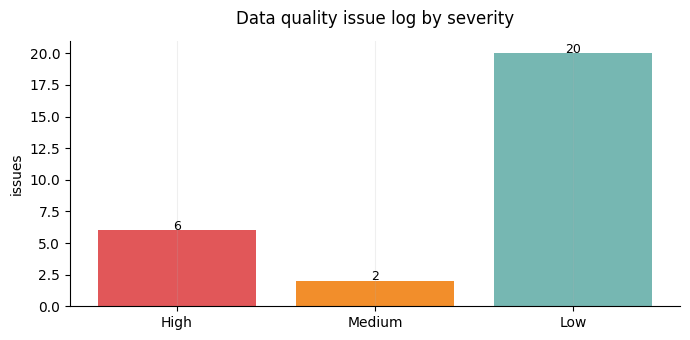

In [ ]:
plot_issue_log_severity(data_quality_issue_log)


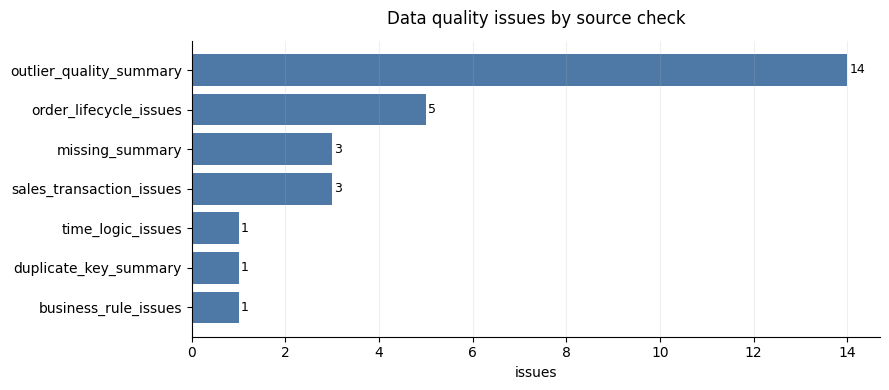

In [ ]:
plot_issue_log_sources(data_quality_issue_log)


### Final data quality conclusion

- Data du tin cay de bat dau EDA, nhung can ghi ro cac issue High/Medium trong `data_quality_issue_log`.
- Cac issue can chu y nhat: `signup_date > order_date`, lifecycle gaps o delivered/returned/shipped, duplicate candidate key trong `order_items`, va sales/payment definition differences.
- Outliers hien tai nen `Flag only`, khong tu dong loai bo truoc EDA.